In [1]:
from astropy import units as u
from astropy import time

import numpy as np

from poliastro import iod
from poliastro.bodies import Body,Mars, Earth, Venus, Jupiter, Saturn, Uranus, Neptune, Sun, Europa, Ganymede, Callisto, Io, Titan
from poliastro.ephem import Ephem
from poliastro.maneuver import Maneuver
from poliastro.twobody import Orbit
from poliastro.util import time_range
from poliastro.plotting import OrbitPlotter3D, StaticOrbitPlotter
import math
import matplotlib.pyplot as plt
# More info: https://plotly.com/python/renderers/
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

from astropy.coordinates import solar_system_ephemeris


solar_system_ephemeris.set("jpl")

<ScienceState solar_system_ephemeris: 'jpl'>

7378 x 19442 km x 0.0 deg (GCRS) orbit around Earth (♁) at epoch 2035-07-18 00:00:00.000 (TDB)


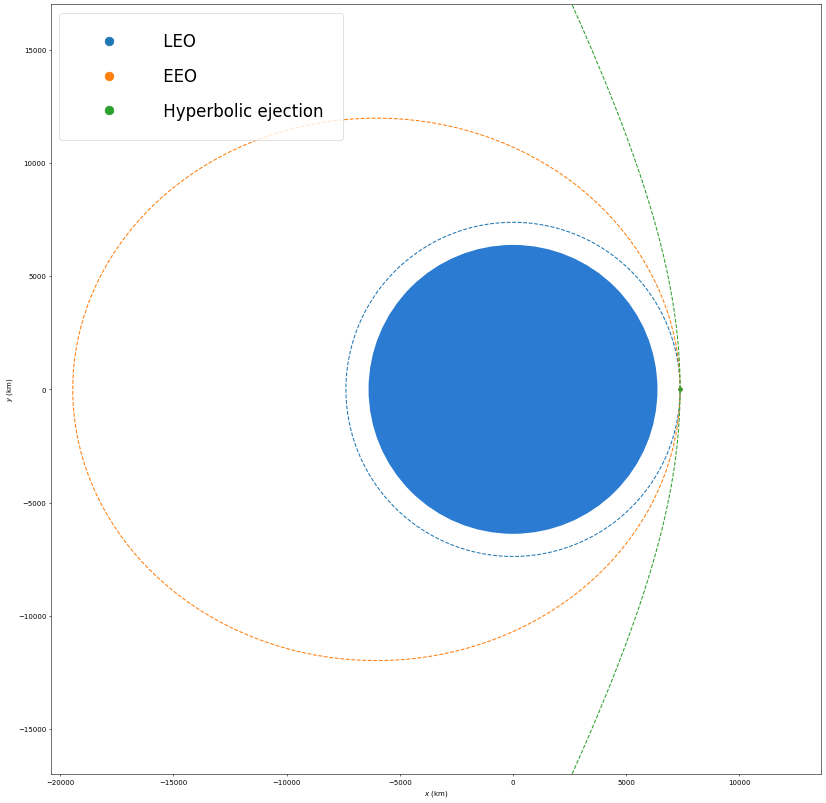

In [15]:
#If the parking orbit is to be elliptical, calculate 

body_1=Earth
date_launch=time.Time("2035-07-18 00:00:00",scale="tdb")

#circular initial
r_p = 1000*u.km#parking orbit
circular_orbit = Orbit.circular(body_1,alt = r_p,epoch = date_launch)
boost=1.5*u.km/u.s
eject=5.5*u.km/u.s
prograde_vector=(circular_orbit.v/(np.linalg.norm(circular_orbit.v))).value

boost_effective_man=Maneuver((0*u.s,boost*prograde_vector))
eject_man=Maneuver((0*u.s,eject*prograde_vector))

parking_orbit=circular_orbit.apply_maneuver(boost_effective_man)
eject=circular_orbit.apply_maneuver(eject_man)

fig, ax = plt.subplots(
    figsize=(20, 20),  # inches
    dpi=50            # resolution
)

plotter=StaticOrbitPlotter(ax)
plotter.plot(circular_orbit, label="LEO",showEpoch=False)
plotter.plot(parking_orbit, label="EEO",showEpoch=False)
plotter.plot(eject, label="Hyperbolic ejection",showEpoch=False)
print(parking_orbit)


legend = ax.legend(
    fontsize=24,
    loc="upper left",
    frameon=True,
    handlelength=3.5,
    handletextpad=1.2,
    markerscale=2.5,   # scales markers globally
    borderpad=1.2,
    labelspacing=1.0,
)
# Get the matplotlib Axes (poliastro versions differ: ax vs _ax)
ax = getattr(plotter, "ax", None) or plotter._ax

# Example: zoom to a +/- 5e8 km box around (0,0)
plot_range=1.7e4
ax.set_xlim(-1.2*plot_range, 0.8*plot_range)
ax.set_ylim(-plot_range, plot_range)
ax.set_aspect("equal", adjustable="box")

plt.show()